In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standardization

In [3]:
df=pd.read_csv('Social_Network_Ads.csv')

In [5]:
df=df.iloc[:,2:]

In [7]:
df.sample(5)

,Age,EstimatedSalary,Purchased
4,19,76000,0
106,26,35000,0
334,57,60000,1
236,40,57000,0
140,19,85000,0


In [17]:
# Train test split 

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [90]:
# Standard Scaler

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

#Learning on train data only
scaler.fit(X_train)

#Transform on train and test both
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
# Converting into dataframe
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [27]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [25]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [29]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


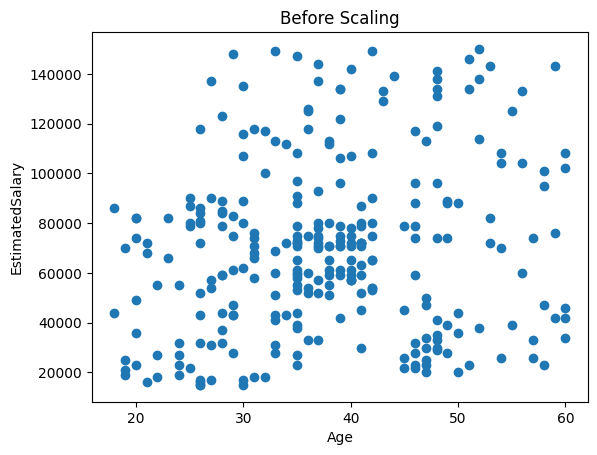

In [54]:
# Scatter plot
plt.scatter(X_train['Age'], X_train['EstimatedSalary'])
plt.title("Before Scaling")
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.show()

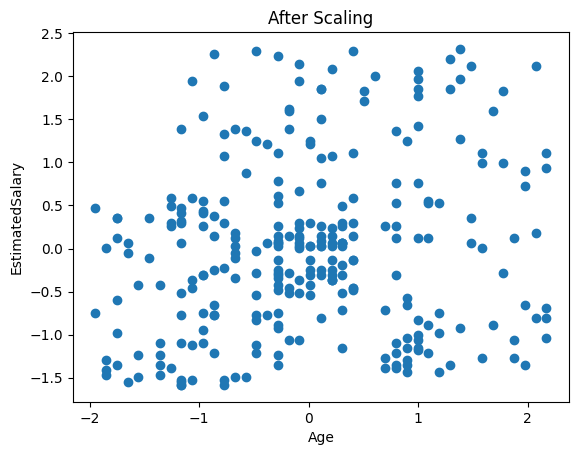

In [56]:
plt.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'])
plt.title("After Scaling")
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.show()

Text(0.5, 1.0, 'Before Scaling')

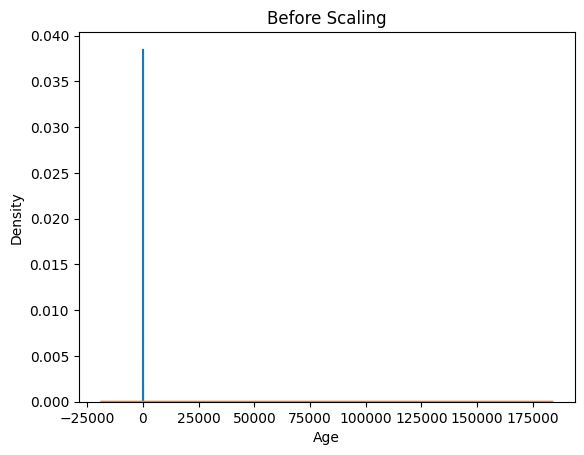

In [62]:
# KDE plot
sns.kdeplot(X_train['Age'])
sns.kdeplot(X_train['EstimatedSalary'])
plt.title("Before Scaling")


Text(0.5, 1.0, 'After Scaling')

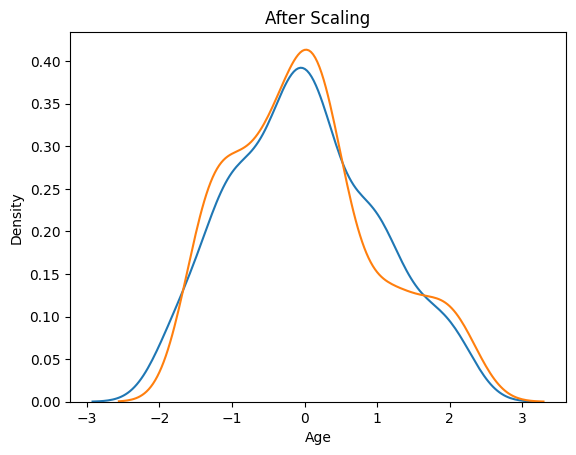

In [64]:
sns.kdeplot(X_train_scaled['Age'])
sns.kdeplot(X_train_scaled['EstimatedSalary'])
plt.title('After Scaling')

# Normalisation

In [74]:
df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])

In [76]:
df.columns=['Class Label','Alcohol','Malic acid']

In [78]:
df

,Class Label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

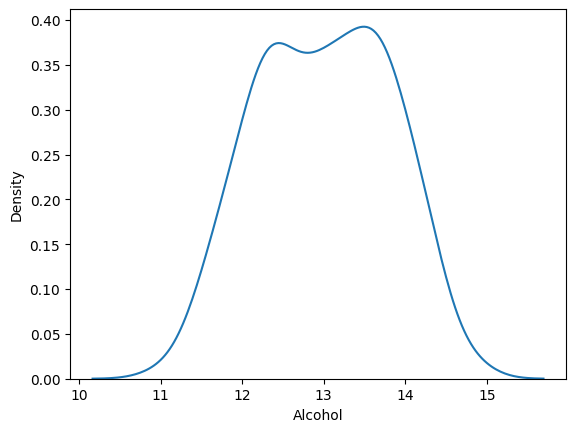

In [80]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

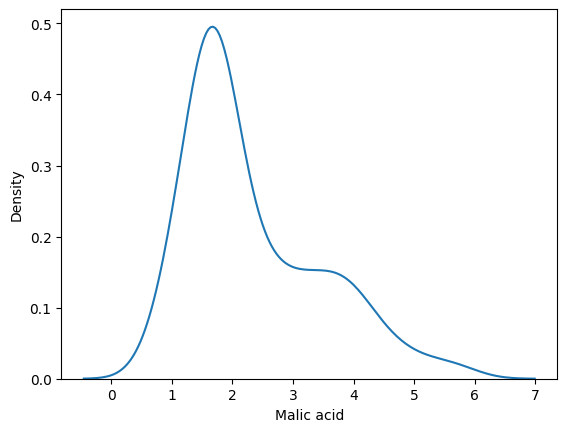

In [82]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

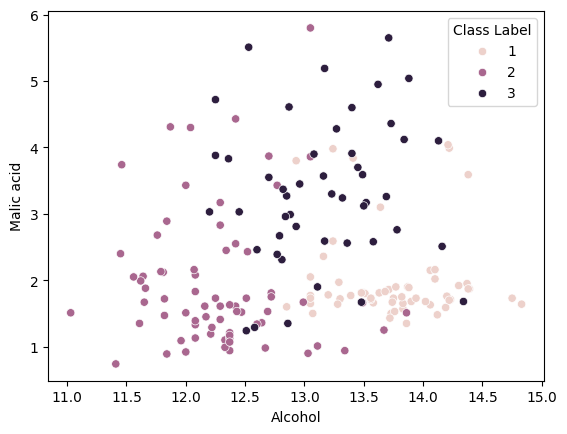

In [88]:
sns.scatterplot(data=df,x='Alcohol',y='Malic acid',hue='Class Label')

In [94]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Class Label',axis=1),df['Class Label'],test_size=0.3,random_state=0)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [96]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_train)

In [100]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [102]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [104]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


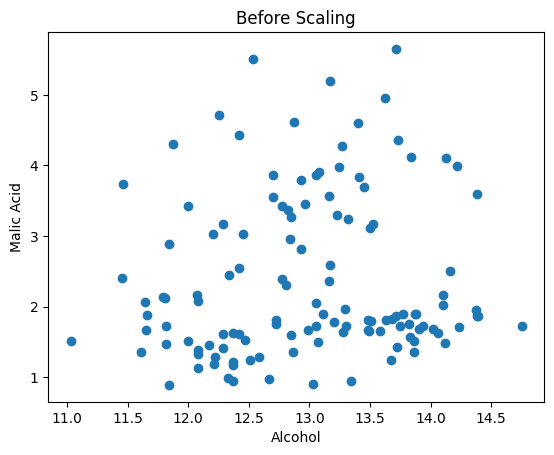

In [128]:
plt.scatter(X_train['Alcohol'],X_train['Malic acid'])
plt.title("Before Scaling")
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.show()

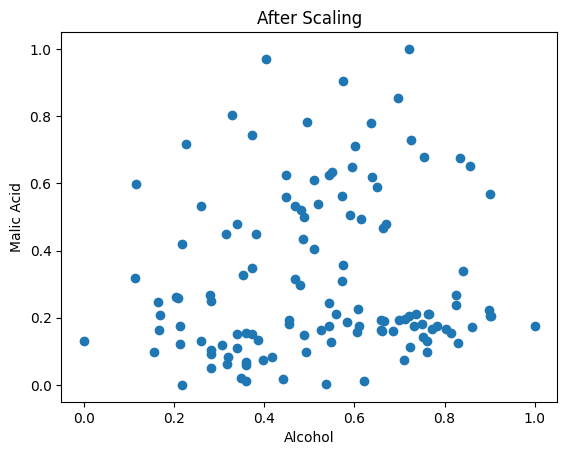

In [112]:
plt.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'])
plt.title("After Scaling")
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.show()

Text(0.5, 1.0, 'Before Scaling')

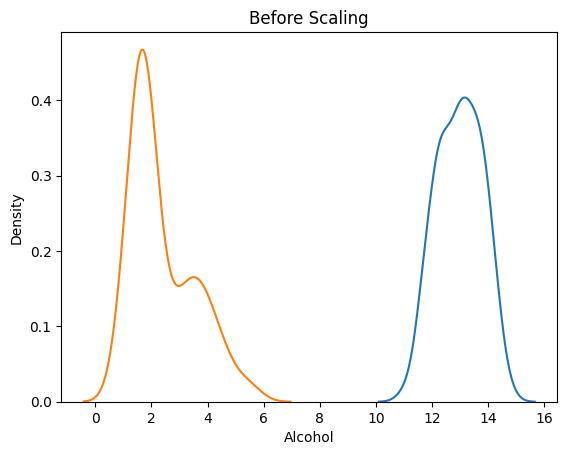

In [114]:
sns.kdeplot(X_train['Alcohol'])
sns.kdeplot(X_train['Malic acid'])
plt.title('Before Scaling')

Text(0.5, 1.0, 'After Scaling')

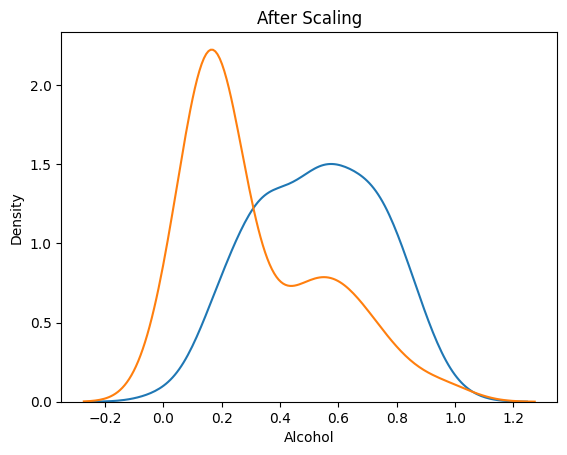

In [116]:
sns.kdeplot(X_train_scaled['Alcohol'])
sns.kdeplot(X_train_scaled['Malic acid'])
plt.title('After Scaling')

In [140]:
# Robust scaling
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()

scaler.fit(X_train)

X_train_Scaled=scaler.transform(X_train)
X_test_Scaled=scaler.transform(X_train)

In [142]:
X_train_Scaled=pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_Scaled=pd.DataFrame(X_test_Scaled,columns=X_test.columns)

In [144]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [146]:
np.round(X_train_Scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,-0.0,0.3
std,0.6,0.7
min,-1.6,-0.6
25%,-0.5,-0.2
50%,0.0,0.0
75%,0.5,0.8
max,1.3,2.3


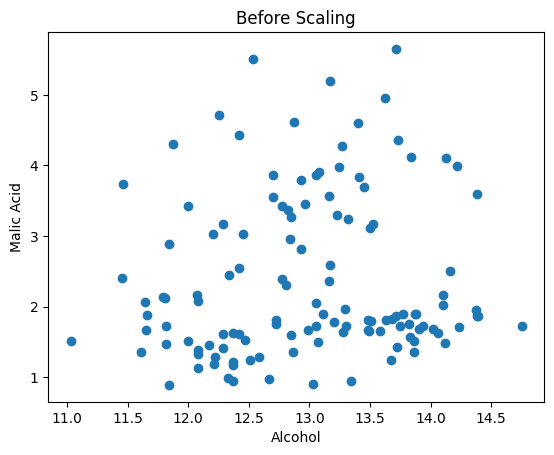

In [148]:
plt.scatter(X_train['Alcohol'],X_train['Malic acid'])
plt.title("Before Scaling")
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.show()

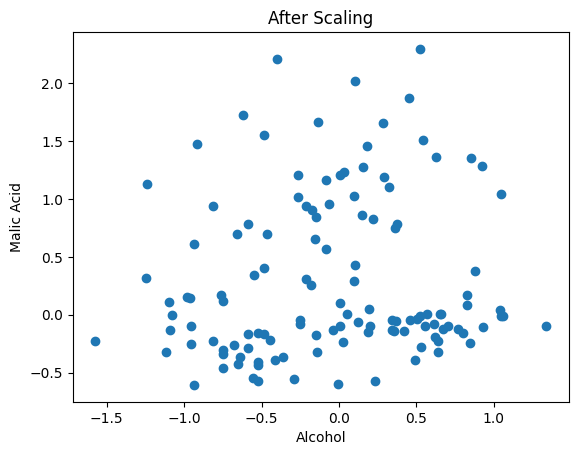

In [150]:
plt.scatter(X_train_Scaled['Alcohol'],X_train_Scaled['Malic acid'])
plt.title("After Scaling")
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.show()

Text(0.5, 1.0, 'Before Scaling')

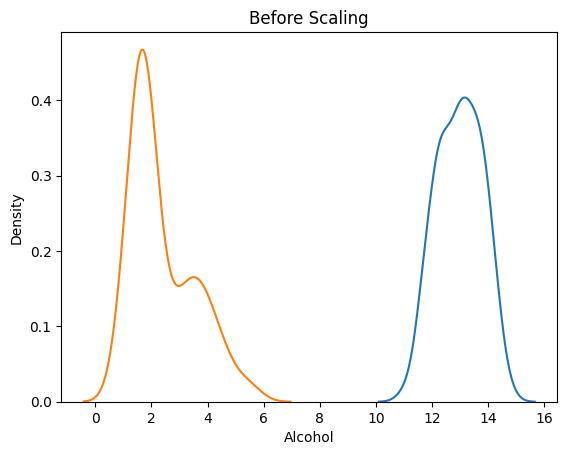

In [134]:
sns.kdeplot(X_train['Alcohol'])
sns.kdeplot(X_train['Malic acid'])
plt.title('Before Scaling')

Text(0.5, 1.0, 'After Scaling')

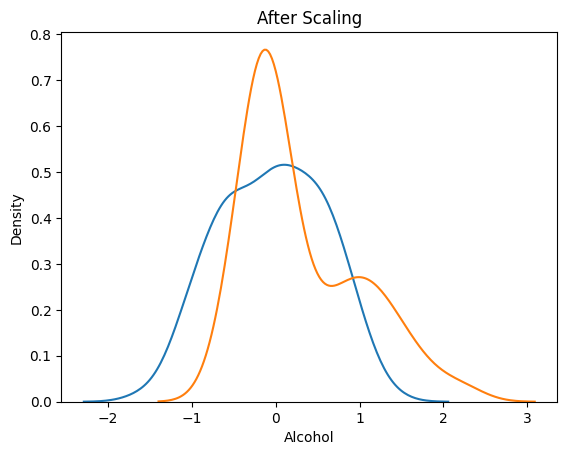

In [152]:
sns.kdeplot(X_train_Scaled['Alcohol'])
sns.kdeplot(X_train_Scaled['Malic acid'])
plt.title('After Scaling')